# Starting Over, Simple — Train / Test / Predict, from Scratch

`22_Forward_Backward_Practice.ipynb` moved too fast, with 5 features and
noise mixed in. This file uses the smallest possible dataset instead —
one feature, numbers you can check by eye — and goes one single step at
a time. Nothing gets typed until you understand *why* it's the next
step, not just what to type.

## Step 1 — Import pandas

`pandas` gives us the `DataFrame` — a table where rows and columns stay
lined up together. Every step below builds on top of a DataFrame, so
this import always comes first, before anything else can run.

In [2]:
import pandas as pd


## Step 2 — Build the dataset by hand

Two plain Python lists, `hours_studied` and `passed`, written in matching
order — position 1 in both lists belongs to student 1, position 2 to
student 2, and so on. `pd.DataFrame({...})` glues the two lists into one
table, column by column.

The last two lines just relabel the row numbers as `Student` (`1` to
`20`) instead of pandas' default `0` to `19` — purely for readability.
`Student` is never treated as real data the model can use; it's only a
name for each row, not a feature.

In [3]:
hours_studied = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
passed = [0,0,0,0,0,0,0,0,0,1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]

dataset = pd.DataFrame({"Hours_Studied": hours_studied, "Passed": passed})
dataset.index = range(1, 21)
dataset.index.name = "Student"
dataset


,Hours_Studied,Passed
Student,,
1,1,0
2,2,0
3,3,0
4,4,0
5,5,0
6,6,0
7,7,0
8,8,0
9,9,0


## Step 3 — Split into X and y

`X` is everything the model is *allowed* to see — here, just
`Hours_Studied`, since we drop `Passed`. `y` is the answer key,
`Passed` on its own, kept separate.

This has to happen before training: if `Passed` stayed inside `X`, the
model could read the real answer straight off its own input instead of
learning a genuine pattern from `Hours_Studied` — the resulting score
would be meaningless.

In [5]:
X = dataset.drop(columns=["Passed"])
y = dataset["Passed"]


## Step 3 (continued) — Confirm the shapes

A quick sanity check before moving on. `X` should come back as a table —
2 numbers, rows and columns — even with only 1 feature column. `y`
should come back as a flat list — 1 number, just a count of values —
since it's a single column pulled out on its own, not a table.

In [6]:
X.shape, y.shape


((20, 1), (20,))

## Step 4 — Split into train and test

We need two separate pools of students: one to actually teach the model
(`X_train`/`y_train`), and a second pool the model never sees during
training (`X_test`/`y_test`) — so there's an honest way to check
afterward whether it learned something real, instead of just memorizing.

- `test_size=0.2` reserves 20% of the 20 students for that second,
  held-back pool.
- `random_state=42` fixes the shuffle, so it's identical every time this
  cell reruns.
- `stratify=y` keeps the pass/fail mix in both pools close to the full
  dataset's mix, instead of risking an unlucky shuffle that dumps most
  of one class into a single pool.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape


((16, 1), (4, 1))

## Step 5 — Build the model, and train it

`DecisionTreeClassifier(max_depth=1, ...)` creates a model that's only
allowed to ask **one single yes/no question** before giving its final
answer — kept this simple on purpose, so every part of it can be
checked by hand.

`model.fit(X_train, y_train)` is the actual training step. Here is
exactly what it does, in order:

1. Look at all 16 training students' `Hours_Studied` values, together
   with their real `Passed` answers.
2. Try every possible dividing line between neighboring `Hours_Studied`
   values in the training data (`1.5, 2.5, 4.0, ... 19.0`).
3. For each candidate line, split the 16 students into a left group and
   a right group. For each group, guess whatever the majority of that
   group actually did — e.g. if most of the left group failed, guess
   "fail" for the whole left group.
4. Count how many real students that guess gets wrong, for every
   candidate line.
5. Keep whichever line makes the *fewest* mistakes. Here, that line is
   `Hours_Studied <= 12.50`, with only 1 mistake out of 16 (student 10,
   who studied just 10 hours but passed anyway).

Nothing here is guesswork — `.fit()` is a brute-force search over every
possible line, scored by mistakes, keeping the best one. It just runs
in milliseconds instead of by hand.

In [8]:

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=1, random_state=42)
model.fit(X_train, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

### Proof: why `12.50` actually wins

Not just an assertion — here's the mistake count for every candidate
line near the middle, computed by hand from the 16 training students:

| candidate line | left group | left guess | mistakes (left) | right group | right guess | mistakes (right) | **total mistakes** |
|---|---|---|---|---|---|---|---|
| 8.5 | 1,2,3,5,6,8 (0 passed) | "fail" | 0 | 9,10,11,12,13,14,15,17,18,20 (7 passed) | "pass" | 3 | 3 |
| 9.5 | 1,2,3,5,6,8,9 (0 passed) | "fail" | 0 | 10,11,12,13,14,15,17,18,20 (7 passed) | "pass" | 2 | 2 |
| 11.5 | 1,2,3,5,6,8,9,10,11 (1 passed) | "fail" | 1 | 12,13,14,15,17,18,20 (6 passed) | "pass" | 1 | 2 |
| **12.5** | **1,2,3,5,6,8,9,10,11,12 (1 passed)** | **"fail"** | **1** | **13,14,15,17,18,20 (6 passed)** | **"pass"** | **0** | **1** |
| 13.5 | 1,2,3,5,6,8,9,10,11,12,13 (2 passed) | "fail" | 2 | 14,15,17,18,20 (5 passed) | "pass" | 0 | 2 |

`12.5` is the only line with just **1** mistake — every neighboring
candidate makes at least 2.

Now the same winning line, but every one of the 16 students listed
individually, so "mistake" has nothing hidden in it:

**Left of `12.5`** — the tree's one guess for this whole group is
"fail" (9 out of 10 actually failed):

| Student | Hours | Real answer | Group's guess | Mistake? |
|---|---|---|---|---|
| 1 | 1 | 0 (failed) | 0 (fail) | No |
| 2 | 2 | 0 | 0 | No |
| 3 | 3 | 0 | 0 | No |
| 5 | 5 | 0 | 0 | No |
| 6 | 6 | 0 | 0 | No |
| 8 | 8 | 0 | 0 | No |
| 9 | 9 | 0 | 0 | No |
| **10** | **10** | **1 (passed)** | **0 (fail)** | **YES** |
| 11 | 11 | 0 | 0 | No |
| 12 | 12 | 0 | 0 | No |

**Right of `12.5`** — the tree's one guess for this whole group is
"pass" (all 6 actually passed):

| Student | Hours | Real answer | Group's guess | Mistake? |
|---|---|---|---|---|
| 13 | 13 | 1 (passed) | 1 (pass) | No |
| 14 | 14 | 1 | 1 | No |
| 15 | 15 | 1 | 1 | No |
| 17 | 17 | 1 | 1 | No |
| 18 | 18 | 1 | 1 | No |
| 20 | 20 | 1 | 1 | No |

`1` mistake on the left (student `10`) `+` `0` mistakes on the right
`=` **1 total mistake** — the number that made `12.5` beat every other
candidate line above.

## Step 6 — Look inside the trained model

`.fit()` doesn't print anything by itself — the tree it built is just
sitting inside `model`, in memory. `export_text()` turns that into a
readable printout, so we can actually see the one question it settled
on (`Hours_Studied <= 12.50`) and what it guesses on each side
(`class: 0` = fail, `class: 1` = pass).

In [9]:
from sklearn.tree import export_text
print(export_text(model, feature_names=["Hours_Studied"]))


|--- Hours_Studied <= 12.50
|   |--- class: 0
|--- Hours_Studied >  12.50
|   |--- class: 1



## Step 7 — See the split as a picture

A number-line plot of all 16 training students, positioned by
`Hours_Studied`, colored by their real `Passed` answer (blue = failed,
orange = passed). The dashed line marks `12.50` — the exact cutoff
`.fit()` found back in Step 5. This is the same result as the
mistake-counting table from Step 5, just drawn instead of counted, so
"1 mistake on the left, 0 mistakes on the right" is visible at a
glance.

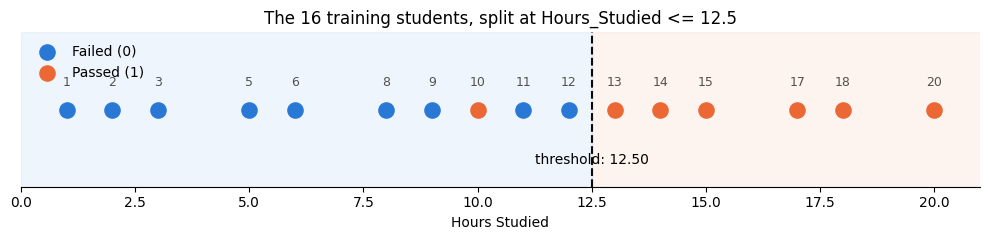

In [10]:
import matplotlib.pyplot as plt

train_view = X_train.join(y_train).sort_values("Hours_Studied")
fail = train_view[train_view["Passed"] == 0]
passed_rows = train_view[train_view["Passed"] == 1]

fig, ax = plt.subplots(figsize=(10, 2.5))

ax.scatter(fail["Hours_Studied"], [0]*len(fail), color="#2a78d6", s=120, label="Failed (0)", zorder=3)
ax.scatter(passed_rows["Hours_Studied"], [0]*len(passed_rows), color="#eb6834", s=120, label="Passed (1)", zorder=3)

for hrs in train_view["Hours_Studied"]:
    ax.text(hrs, 0.15, str(hrs), ha="center", fontsize=9, color="#52514e")

ax.axvline(12.5, color="#0b0b0b", linestyle="--", linewidth=1.5)
ax.text(12.5, -0.35, "threshold: 12.50", ha="center", fontsize=10)
ax.axvspan(0, 12.5, color="#2a78d6", alpha=0.07)
ax.axvspan(12.5, 21, color="#eb6834", alpha=0.07)

ax.set_xlim(0, 21)
ax.set_ylim(-0.5, 0.5)
ax.set_yticks([])
ax.set_xlabel("Hours Studied")
ax.set_title("The 16 training students, split at Hours_Studied <= 12.5")
ax.legend(loc="upper left", frameon=False)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


## Step 8 — Predict on the test set

`model.predict(X_test)` runs the **one** rule `.fit()` found
(`Hours_Studied <= 12.50` → fail, else pass) against the 4 students the
model has never seen, and returns one guess per row, in the same row
order as `X_test`.

In [11]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
y_pred


array([0, 1, 1, 0])

## Step 8 (continued) — The real answers, to compare against

`y_test` never got shown to the model at any point — not during
`.fit()`, not during `.predict()`. Printing it now, only *after* the
guesses already exist, is purely for grading — same rule as the
flashcard story from Step 4.

In [12]:
y_test


Student
4     0
19    1
16    1
7     0
Name: Passed, dtype: int64

## Step 9 — Turn the comparison into one score

`accuracy_score(y_test, y_pred)` lines up both lists row by row, counts
how many match, and divides by the total. Exactly the same "count the
mistakes" idea from Step 5 — just run once, on 4 brand-new students the
rule has never seen before.

In [13]:
accuracy_score(y_test, y_pred)


1.0

### The result: 100% — checked by hand

All 4 test students, using nothing but the single rule
`Hours_Studied <= 12.50`:

| Student | Hours | Rule says | Real answer | Match? |
|---|---|---|---|---|
| 4 | 4 | `4 <= 12.50` → fail (0) | 0 | Yes |
| 7 | 7 | `7 <= 12.50` → fail (0) | 0 | Yes |
| 16 | 16 | `16 > 12.50` → pass (1) | 1 | Yes |
| 19 | 19 | `19 > 12.50` → pass (1) | 1 | Yes |

4 out of 4 correct → `accuracy_score` returns `1.0`. Worth noticing: this
isn't the *guaranteed* outcome of training a model — it's a genuinely
good result here because the test students all happened to sit clearly
on one side of `12.50` or the other, nowhere near the messy middle where
student `10` and student `12` live. A tiny test set like this (just 4
students) also means every single row matters a lot to the score — one
wrong guess here would have dropped it straight to `0.75`.

That's the full loop, start to finish: build data → split → train →
inspect → predict → grade. Same shape as `20_Feature_Selection_techniques.ipynb`
and `22_Forward_Backward_Practice.ipynb`, just small enough this time to
verify every single number by hand.